In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.rcParams["figure.figsize"]=(10,6)

In [11]:
matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

In [15]:
matches.head()
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [16]:
matches.info()
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [18]:
matches.shape
deliveries.shape

(260920, 17)

matches.isnull().sum()
deliveries.isnul().

In [22]:
matches.isnull().sum()
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [23]:
matches.duplicated().sum()
deliveries.duplicated().sum()

np.int64(0)

In [24]:
matches['team1'].unique()

<StringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [26]:
matches.replace({'Delhi Daredevils':'Delhi Capitals'}, inplace = True)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


In [27]:
matches.to_csv('../data/cleaned/matches_clean.csv', index = False)
deliveries.to_csv('../data/cleaned/deliveries_clean.csv', index = False)

In [28]:
print("Total Matches:",matches.shape[0])

Total Matches: 1095


In [29]:
matches['season'].value_counts()

season
2013       76
2012       74
2022       74
2023       74
2011       73
2024       71
2009/10    60
2014       60
2016       60
2018       60
2019       60
2020/21    60
2021       60
2015       59
2017       59
2007/08    58
2009       57
Name: count, dtype: int64

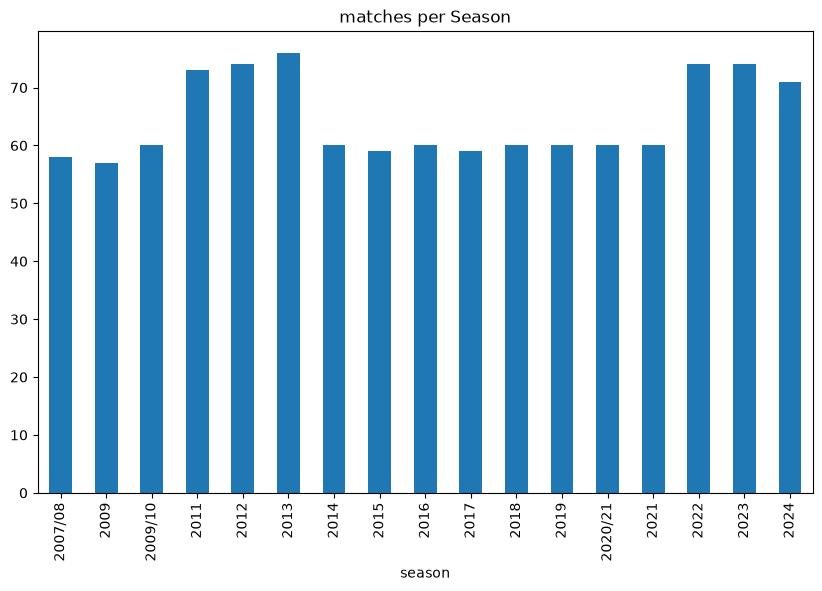

In [30]:
matches['season'].value_counts().sort_index().plot(kind='bar')
plt.title("matches per Season")
plt.show()

In [32]:
wins = matches['winner'].value_counts()
wins.head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Delhi Capitals                 115
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Name: count, dtype: int64

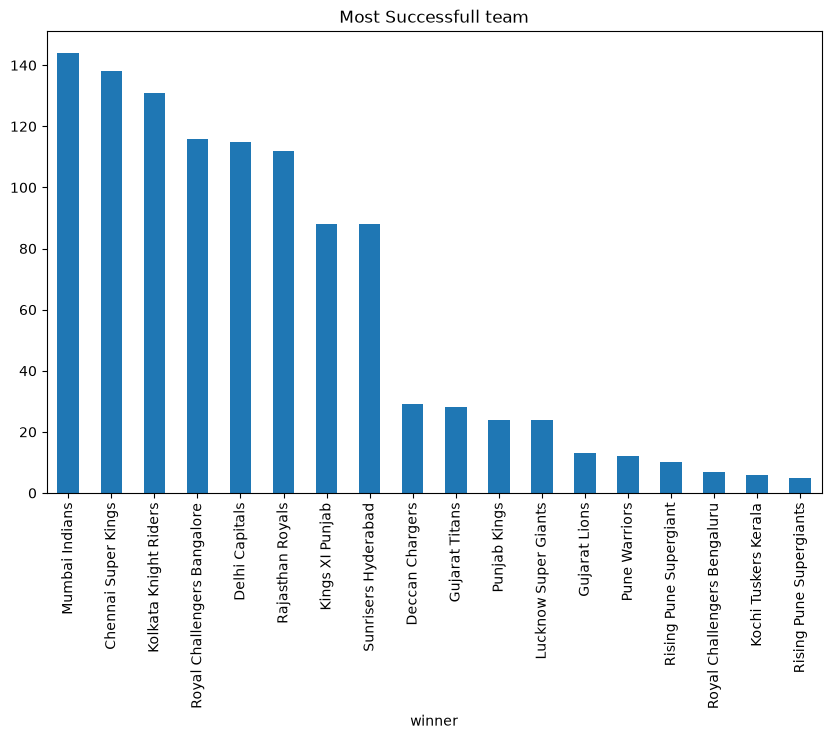

In [39]:
wins.plot(kind = 'bar')
plt.title('Most Successfull team')
plt.savefig("../images/team_wins.png")
plt.show()

In [41]:
toss_match_win = (matches['toss_winner'] == matches['winner']).mean()*100
print(toss_match_win)

50.593607305936075


In [42]:
top_batsmen = deliveries.groupby('batter')['total_runs'].sum()
top_batsmen.sort_values(ascending = False).head(10)

batter
V Kohli           8307
S Dhawan          7119
DA Warner         6910
RG Sharma         6884
SK Raina          5780
MS Dhoni          5505
AB de Villiers    5354
CH Gayle          5336
RV Uthappa        5246
KD Karthik        5066
Name: total_runs, dtype: int64

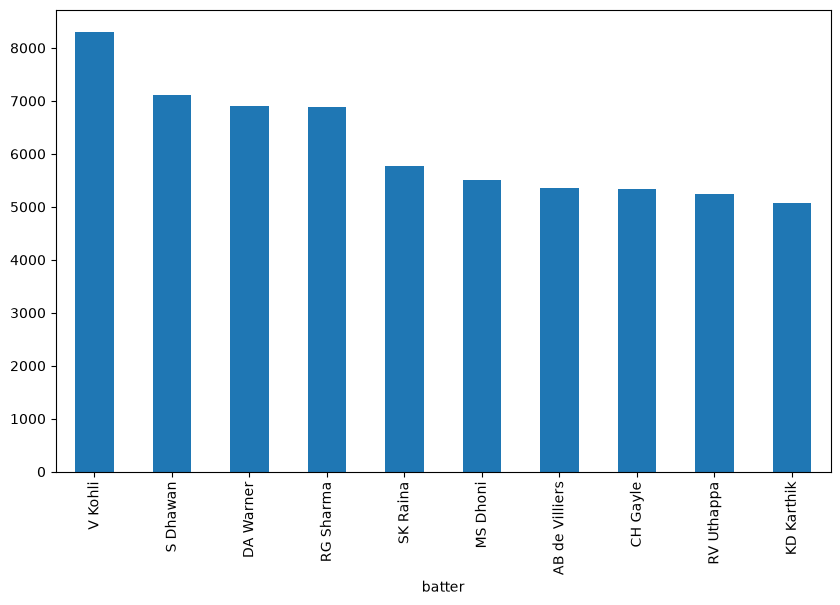

In [43]:
top_batsmen.sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.savefig('../images/top_batsmen.png')
plt.show()

In [45]:
top_bowlers = deliveries.groupby('bowler')['is_wicket'].sum()
top_bowlers.sort_values(ascending = False).head(10)

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64

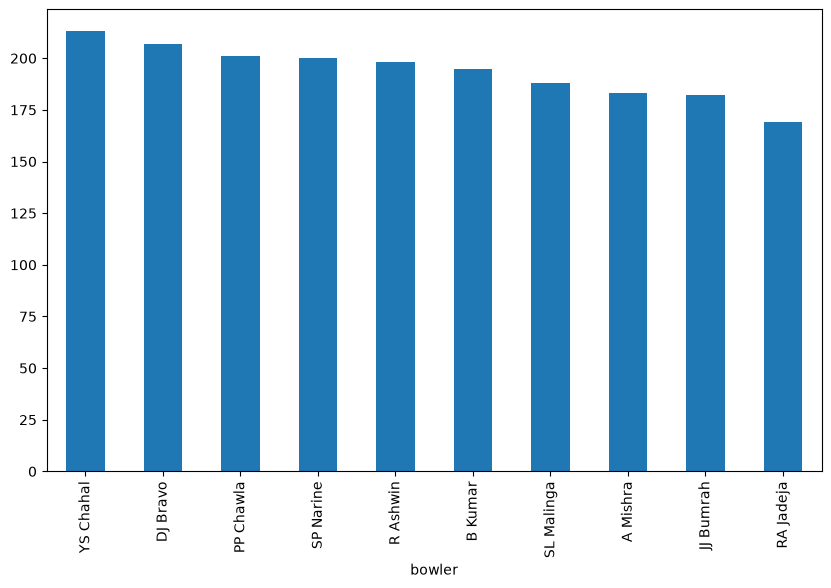

In [46]:
top_bowlers.sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.savefig('../images/top_bowlers.png')
plt.show()

In [48]:
sixes = deliveries[deliveries['batsman_runs']==6]
sixes.groupby('batter').size().sort_values(ascending = False).head(10)

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
dtype: int64

In [49]:
fours = deliveries[deliveries['batsman_runs']==4]
fours.groupby('batter').size().sort_values(ascending = False).head(10)

batter
S Dhawan        768
V Kohli         708
DA Warner       663
RG Sharma       599
SK Raina        506
G Gambhir       492
RV Uthappa      481
AM Rahane       479
KD Karthik      466
F du Plessis    422
dtype: int64

In [56]:
matches['player_of_match'].value_counts().head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
SP Narine         15
Name: count, dtype: int64